# Sen1Floods11 Weak Label Viability (No-Model)


## Imports

**What it does:** Imports only the allowed libraries and defines a lightweight `progress_print` helper.
**Why it matters:** Keeps the notebook dependency-light and reproducible for label QA.
**Outputs:** No data outputs; just setup for later cells.
**How to interpret:** If this cell runs, the environment is ready for all analyses below.
**Assumptions / runtime:** Assumes these libraries are installed in the environment.


In [1]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

%matplotlib inline

def progress_print(i, n, every=50, label=""):
    if n == 0:
        return
    if (i == 0) or (i + 1 == n) or ((i + 1) % every == 0):
        prefix = f"[{label}] " if label else ""
        print(f"{prefix}{i+1}/{n}")


## Config

**What it does:** Sets dataset paths, thresholds, and runtime controls for the analysis.
**Why it matters:** Consistent configuration makes weak-vs-strong comparisons fair and repeatable.
**Outputs:** Prints the output directory path and creates it if needed.
**How to interpret:** Adjust thresholds here to test sensitivity; lower thresholds generally make the analysis stricter.
**Assumptions / runtime:** Paths are valid on disk; high-resolution tiles may increase runtime.


In [2]:
# ---- Config ----
DATA_ROOT = r"C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\26-S-Lockheed-2\datasets\FilteredSouthAsia"
IMG_DIR = r"WeaklyLabeled/S1Weak"
MASK_DIR = r"WeaklyLabeled/S1OtsuLabelWeak"
STRONG_MASK_DIR = r"HandLabeled/LabelHand"  # optional
STRONG_IMG_DIR = r"HandLabeled/S1Hand"  # optional (paired with LabelHand)
OUT_DIR = "outputs_weak_label_viability"  # under DATA_ROOT

BEFORE_MASK_DIR = None  # e.g., "before_weak_masks" or None

FLOOD_POS_VALUES = {1, 255}
EMPTY_THRESH = 0.0
FULL_THRESH = 0.90

TINY_COMPONENT_PIXELS = 64
MAX_TILES_TO_VISUALIZE = 12
MAX_TILES = None  # set to int for quick runs

PROGRESS_EVERY = 50
MAX_CC_TILES = 200
DOWNSAMPLE_FACTOR = 2
DILATION_R = 1

# Suspect rule thresholds
STRONG_NONTRIVIAL_FLOOD = 0.02
WEAK_NEAR_EMPTY = 0.001
FLOOD_FRACTION_DELTA_LARGE = 0.25
BOUNDARY_F1_LOW = 0.2
TINY_COMPONENT_RATIO_HIGH = 0.4

out_path = Path(DATA_ROOT) / OUT_DIR
out_path.mkdir(parents=True, exist_ok=True)
print("Output dir:", out_path)


Output dir: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\26-S-Lockheed-2\datasets\FilteredSouthAsia\outputs_weak_label_viability


## Index Tiles And Masks

**What it does:** Builds separate weak and strong tile indices using image/mask stems.
**Why it matters:** Keeps weak and strong sets independent for no-overlap distributional comparison.
**Outputs:** Printed counts for weak/strong images and masks, aligned weak tiles, aligned strong tiles; `index_df` and `strong_index_df`.
**How to interpret:** Large imbalances between sets may affect distributional uncertainty.
**Assumptions / runtime:** Filenames share a common stem; duplicates are ignored after the first occurrence.


In [3]:
# ---- File Indexing ----
if "DATA_ROOT" not in globals():
    raise RuntimeError("DATA_ROOT is not set. Run the Config cell first.")
if "IMG_DIR" not in globals():
    raise RuntimeError("IMG_DIR is not set. Run the Config cell first.")
if "MASK_DIR" not in globals():
    raise RuntimeError("MASK_DIR is not set. Run the Config cell first.")
if "STRONG_MASK_DIR" not in globals():
    STRONG_MASK_DIR = None
if "STRONG_IMG_DIR" not in globals():
    STRONG_IMG_DIR = None

def base_id_from_stem(stem):
    if "_" in stem:
        return stem.rsplit("_", 1)[0]
    return stem

img_root = Path(DATA_ROOT) / IMG_DIR
mask_root = Path(DATA_ROOT) / MASK_DIR
strong_root = Path(DATA_ROOT) / STRONG_MASK_DIR if STRONG_MASK_DIR else None
strong_img_root = Path(DATA_ROOT) / STRONG_IMG_DIR if STRONG_IMG_DIR else None

img_paths = sorted(glob.glob(str(img_root / "*.tif")))
mask_paths = sorted(glob.glob(str(mask_root / "*.tif")))

img_map = {}
img_dupes = []
for p in img_paths:
    base = base_id_from_stem(Path(p).stem)
    if base in img_map:
        img_dupes.append(base)
        continue
    img_map[base] = p

mask_map = {}
mask_dupes = []
for p in mask_paths:
    base = base_id_from_stem(Path(p).stem)
    if base in mask_map:
        mask_dupes.append(base)
        continue
    mask_map[base] = p

strong_img_map = {}
strong_img_paths = []
if strong_img_root and strong_img_root.exists():
    strong_img_paths = sorted(glob.glob(str(strong_img_root / "*.tif")))
    for p in strong_img_paths:
        base = base_id_from_stem(Path(p).stem)
        if base in strong_img_map:
            continue
        strong_img_map[base] = p

strong_map = {}
strong_paths = []
if strong_root and strong_root.exists():
    strong_paths = sorted(glob.glob(str(strong_root / "*.tif")))
    for p in strong_paths:
        base = base_id_from_stem(Path(p).stem)
        if base in strong_map:
            continue
        strong_map[base] = p

aligned_ids = sorted(set(img_map.keys()) & set(mask_map.keys()))
rows = []
for s in aligned_ids:
    rows.append({
        "tile_id": s,
        "img_path": img_map[s],
        "weak_mask_path": mask_map[s]
    })

if len(rows) == 0:
    index_df = pd.DataFrame(columns=["tile_id", "img_path", "weak_mask_path"])
else:
    index_df = pd.DataFrame(rows).sort_values("tile_id").reset_index(drop=True)

strong_aligned_ids = sorted(set(strong_img_map.keys()) & set(strong_map.keys()))
strong_rows = []
for s in strong_aligned_ids:
    strong_rows.append({
        "tile_id": s,
        "strong_img_path": strong_img_map[s],
        "strong_mask_path": strong_map[s]
    })
if len(strong_rows) == 0:
    strong_index_df = pd.DataFrame(columns=["tile_id", "strong_img_path", "strong_mask_path"])
else:
    strong_index_df = pd.DataFrame(strong_rows).sort_values("tile_id").reset_index(drop=True)

total_weak_tiles = len(mask_paths)
total_strong_tiles = len(strong_paths)
total_strong_images = len(strong_img_paths)

print("Weak images:", len(img_paths))
print("Weak masks:", total_weak_tiles)
print("Aligned weak img+mask:", len(index_df))
print("Strong images:", total_strong_images)
print("Strong masks:", total_strong_tiles)
print("Aligned strong img+mask:", len(strong_index_df))

if img_dupes:
    print("Image duplicate base ids (ignored):", len(img_dupes))
if mask_dupes:
    print("Weak mask duplicate base ids (ignored):", len(mask_dupes))

missing_img = sorted(set(mask_map.keys()) - set(img_map.keys()))
missing_mask = sorted(set(img_map.keys()) - set(mask_map.keys()))
print("Missing images for weak masks:", len(missing_img))
print("Missing weak masks for images:", len(missing_mask))

if len(index_df) == 0:
    print("No aligned weak tiles found. Check IMG_DIR/MASK_DIR and filename suffixes.")

if MAX_TILES is not None and len(index_df) > 0:
    index_df = index_df.head(MAX_TILES).reset_index(drop=True)
    print("Using MAX_TILES (weak):", len(index_df))

print("Weak tiles after MAX_TILES:", len(index_df))

index_df.head()


Weak images: 906
Weak masks: 906
Aligned weak img+mask: 906
Strong images: 138
Strong masks: 138
Aligned strong img+mask: 138
Missing images for weak masks: 0
Missing weak masks for images: 0
Weak tiles after MAX_TILES: 906


,tile_id,img_path,weak_mask_path
0,India_1029501,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...
1,India_1064251,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...
2,India_1068450,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...
3,India_1080875,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...
4,India_1098917,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...,C:\Users\bumba\OneDrive\Documents\Spring 26\Lo...


## Raster And Mask Utilities

**What it does:** Defines raster readers, mask binarization, and Sentinel-1 band access helpers.
**Why it matters:** Ensures all masks are consistently turned into 0/1 arrays for fair metric comparisons.
**Outputs:** No immediate outputs; functions are used throughout the notebook.
**How to interpret:** `read_mask` returns uint8 masks with flood pixels set to 1.
**Assumptions / runtime:** Masks are single-band or flood labels are in the first band; nodata is treated as non-flood.


In [4]:
# ---- Raster Utilities ----

def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read()
        profile = src.profile
    return arr, profile


def read_mask(path):
    arr, profile = read_raster(path)
    if arr.ndim == 3:
        arr = arr[0]
    nodata = profile.get("nodata", None)
    if nodata is not None:
        arr = np.where(arr == nodata, 0, arr)
    mask = np.zeros_like(arr, dtype=np.uint8)
    for v in FLOOD_POS_VALUES:
        mask |= (arr == v)
    return mask.astype(np.uint8)


def read_s1_bands(img_arr, profile):
    if img_arr.ndim == 2:
        vv = img_arr.astype(np.float32)
        vh = None
        return vv, vh
    if img_arr.shape[0] >= 2:
        vv = img_arr[0].astype(np.float32)
        vh = img_arr[1].astype(np.float32)
    else:
        vv = img_arr[0].astype(np.float32)
        vh = None
    return vv, vh


def safe_sample(arr, mask=None):
    if mask is None:
        s = arr[np.isfinite(arr)]
    else:
        s = arr[(mask > 0) & np.isfinite(arr)]
    return s


## Numpy-Only Metric Helpers

**Purpose:** Provide small numpy-only helpers reused by the viability metrics.
**Inputs/outputs:** Inputs are numeric arrays; outputs are cleaned arrays and robust summary scalars.
**Why it matters:** Stable summaries (e.g., IQR) support robust metric comparisons without overlap.


In [5]:
# ---- Numpy Metric Helpers ----

def finite_vals(arr):
    a = np.asarray(arr, dtype=float)
    return a[np.isfinite(a)]

def iqr(arr):
    a = finite_vals(arr)
    if a.size == 0:
        return np.nan
    q75, q25 = np.percentile(a, [75, 25])
    return float(q75 - q25)


## Per-tile Metrics (Shared Extractor)

**Purpose:** Define a single numpy-only metric extractor used for both weak and strong tiles.
**Inputs/outputs:** Inputs are `img_path`, `mask_path`, and `tile_id`; output is one dict of morphology, plausibility, and edge metrics per tile.
**Why it matters:** Using identical metrics for both sets enables distributional comparison without overlap, which is the core viability test.


In [6]:
# ---- Per-tile Metrics (Shared Extractor) ----
TINY_COMPONENT_PIXELS = int(globals().get("TINY_COMPONENT_PIXELS", 64))
PROGRESS_EVERY = int(globals().get("PROGRESS_EVERY", 25))
EDGE_SAMPLES = int(globals().get("EDGE_SAMPLES", 5000))
EDGE_RNG_SEED = 1337

def _binary(mask):
    if mask is None:
        return None
    return (mask > 0).astype(np.uint8)

def _boundary(mask_bin):
    m = mask_bin.astype(bool)
    if m.size == 0:
        return m
    up = np.zeros_like(m)
    down = np.zeros_like(m)
    left = np.zeros_like(m)
    right = np.zeros_like(m)
    up[1:] = m[:-1]
    down[:-1] = m[1:]
    left[:, 1:] = m[:, :-1]
    right[:, :-1] = m[:, 1:]
    interior = m & up & down & left & right
    return m & (~interior)

def _count_components(mask_bin):
    m = mask_bin.astype(bool)
    h, w = m.shape
    visited = np.zeros_like(m, dtype=bool)
    sizes = []
    if m.sum() == 0:
        return sizes
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]
    for y in range(h):
        for x in range(w):
            if m[y, x] and not visited[y, x]:
                stack = [(y, x)]
                visited[y, x] = True
                size = 0
                while stack:
                    cy, cx = stack.pop()
                    size += 1
                    for dy, dx in neighbors:
                        ny = cy + dy
                        nx = cx + dx
                        if ny < 0 or ny >= h or nx < 0 or nx >= w:
                            continue
                        if m[ny, nx] and not visited[ny, nx]:
                            visited[ny, nx] = True
                            stack.append((ny, nx))
                sizes.append(size)
    return sizes

def _grad_mag(arr):
    a = arr.astype(np.float32)
    gy = np.zeros_like(a)
    gx = np.zeros_like(a)
    if a.shape[0] > 1:
        gy[1:-1, :] = 0.5 * (a[2:, :] - a[:-2, :])
        gy[0, :] = a[1, :] - a[0, :]
        gy[-1, :] = a[-1, :] - a[-2, :]
    if a.shape[1] > 1:
        gx[:, 1:-1] = 0.5 * (a[:, 2:] - a[:, :-2])
        gx[:, 0] = a[:, 1] - a[:, 0]
        gx[:, -1] = a[:, -1] - a[:, -2]
    return np.sqrt(gx * gx + gy * gy)

def _edge_alignment_score(vv, boundary_bin, samples=EDGE_SAMPLES):
    if vv is None or boundary_bin is None:
        return np.nan
    if vv.shape != boundary_bin.shape:
        return np.nan
    grad = _grad_mag(vv)
    grad_flat = grad.reshape(-1)
    boundary_flat = boundary_bin.reshape(-1).astype(bool)
    valid_flat = np.isfinite(grad_flat)
    b_idx = np.flatnonzero(boundary_flat & valid_flat)
    nb_idx = np.flatnonzero((~boundary_flat) & valid_flat)
    if b_idx.size == 0 or nb_idx.size == 0:
        return np.nan
    rng = np.random.default_rng(EDGE_RNG_SEED)
    b_take = min(samples, b_idx.size)
    nb_take = min(samples, nb_idx.size)
    b_sample = rng.choice(b_idx, size=b_take, replace=False)
    nb_sample = rng.choice(nb_idx, size=nb_take, replace=False)
    b_vals = grad_flat[b_sample]
    nb_vals = grad_flat[nb_sample]
    nb_iqr = iqr(nb_vals)
    if not np.isfinite(nb_iqr) or nb_iqr <= 1e-8:
        return np.nan
    score = (float(np.median(b_vals)) - float(np.median(nb_vals))) / nb_iqr
    return float(score)

def _masked_mean(arr, mask):
    vals = safe_sample(arr, mask)
    if vals.size == 0:
        return np.nan
    return float(vals.mean())

METRIC_COLUMNS = [
    "tile_id",
    "flood_fraction",
    "mask_area_px",
    "n_components",
    "largest_component_fraction",
    "tiny_component_ratio",
    "boundary_length_px",
    "boundary_to_area_ratio",
    "vv_flood_mean",
    "vv_nonflood_mean",
    "delta_vv_nonflood_minus_flood",
    "vh_flood_mean",
    "vh_nonflood_mean",
    "delta_vh_nonflood_minus_flood",
    "edge_alignment_score"
]

def compute_tile_metrics(img_path, mask_path, tile_id):
    mask = read_mask(mask_path)
    mask_bin = _binary(mask)
    mask_area_px = int(mask_bin.sum())
    flood_fraction = float(mask_bin.mean()) if mask_bin.size > 0 else 0.0

    comp_sizes = _count_components(mask_bin)
    n_components = int(len(comp_sizes))
    if n_components == 0:
        largest_component_fraction = np.nan
        tiny_component_ratio = np.nan
    else:
        largest_component_fraction = float(max(comp_sizes) / max(mask_area_px, 1))
        tiny_component_ratio = float(np.mean(np.array(comp_sizes) < TINY_COMPONENT_PIXELS))

    boundary_bin = _boundary(mask_bin)
    boundary_length_px = int(boundary_bin.sum())
    boundary_to_area_ratio = (boundary_length_px / mask_area_px) if mask_area_px > 0 else np.nan

    img_arr, img_prof = read_raster(img_path)
    vv, vh = read_s1_bands(img_arr, img_prof)

    if vv is not None and vv.shape == mask_bin.shape:
        f_mask = mask_bin.astype(np.uint8)
        nf_mask = (~mask_bin.astype(bool)).astype(np.uint8)
        vv_flood_mean = _masked_mean(vv, f_mask)
        vv_nonflood_mean = _masked_mean(vv, nf_mask)
        if np.isfinite(vv_flood_mean) and np.isfinite(vv_nonflood_mean):
            delta_vv = float(vv_nonflood_mean - vv_flood_mean)
        else:
            delta_vv = np.nan

        if vh is not None:
            vh_flood_mean = _masked_mean(vh, f_mask)
            vh_nonflood_mean = _masked_mean(vh, nf_mask)
            if np.isfinite(vh_flood_mean) and np.isfinite(vh_nonflood_mean):
                delta_vh = float(vh_nonflood_mean - vh_flood_mean)
            else:
                delta_vh = np.nan
        else:
            vh_flood_mean = np.nan
            vh_nonflood_mean = np.nan
            delta_vh = np.nan

        edge_alignment = _edge_alignment_score(vv, boundary_bin, samples=EDGE_SAMPLES)
    else:
        vv_flood_mean = np.nan
        vv_nonflood_mean = np.nan
        delta_vv = np.nan
        vh_flood_mean = np.nan
        vh_nonflood_mean = np.nan
        delta_vh = np.nan
        edge_alignment = np.nan

    return {
        "tile_id": tile_id,
        "flood_fraction": flood_fraction,
        "mask_area_px": mask_area_px,
        "n_components": n_components,
        "largest_component_fraction": largest_component_fraction,
        "tiny_component_ratio": tiny_component_ratio,
        "boundary_length_px": boundary_length_px,
        "boundary_to_area_ratio": boundary_to_area_ratio,
        "vv_flood_mean": vv_flood_mean,
        "vv_nonflood_mean": vv_nonflood_mean,
        "delta_vv_nonflood_minus_flood": delta_vv,
        "vh_flood_mean": vh_flood_mean,
        "vh_nonflood_mean": vh_nonflood_mean,
        "delta_vh_nonflood_minus_flood": delta_vh,
        "edge_alignment_score": edge_alignment
    }


## Weak Metrics (Full Suite)

**Purpose:** Compute the full per-tile metric suite for all weak tiles.
**Inputs/outputs:** Inputs are `index_df`, `compute_tile_metrics`, and weak mask/image paths; outputs are `weak_metrics_df` and `weak_metrics_full.csv`.
**Why it matters:** These metrics define the weak-label distribution we compare against strong labels in a no-overlap setting.


In [7]:
# ---- Weak Metrics (Full Suite) ----
weak_rows = []
n = len(index_df)
for i, row in enumerate(index_df.itertuples(index=False)):
    progress_print(i, n, PROGRESS_EVERY, label="weak-metrics")
    metrics = compute_tile_metrics(row.img_path, row.weak_mask_path, row.tile_id)
    weak_rows.append(metrics)

weak_metrics_df = pd.DataFrame(weak_rows, columns=METRIC_COLUMNS)
weak_metrics_df.to_csv(out_path / "weak_metrics_full.csv", index=False)

weak_metrics_df.head()


[weak-metrics] 1/906
[weak-metrics] 50/906
[weak-metrics] 100/906
[weak-metrics] 150/906
[weak-metrics] 200/906
[weak-metrics] 250/906
[weak-metrics] 300/906
[weak-metrics] 350/906
[weak-metrics] 400/906
[weak-metrics] 450/906
[weak-metrics] 500/906
[weak-metrics] 550/906
[weak-metrics] 600/906
[weak-metrics] 650/906
[weak-metrics] 700/906
[weak-metrics] 750/906
[weak-metrics] 800/906
[weak-metrics] 850/906
[weak-metrics] 900/906
[weak-metrics] 906/906


,tile_id,flood_fraction,mask_area_px,n_components,largest_component_fraction,tiny_component_ratio,boundary_length_px,boundary_to_area_ratio,vv_flood_mean,vv_nonflood_mean,delta_vv_nonflood_minus_flood,vh_flood_mean,vh_nonflood_mean,delta_vh_nonflood_minus_flood,edge_alignment_score
0,India_1029501,0.003685,966,11,0.478261,0.636364,300,0.310559,-13.041353,-7.317102,5.724251,-23.447515,-13.970287,9.477228,0.089567
1,India_1064251,0.024445,6408,37,0.435861,0.540541,1334,0.208177,-14.648875,-8.735232,5.913643,-24.122663,-14.958120,9.164543,0.139640
2,India_1068450,0.559757,146737,4,0.929895,0.000000,3212,0.021890,-24.111168,-10.570739,13.540429,-29.209784,-15.568616,13.641168,1.111318
3,India_1080875,0.876556,229784,3,0.999412,0.333333,3940,0.017147,-19.399288,-8.616358,10.782930,-28.814312,-15.355706,13.458606,0.552115
4,India_1098917,0.009842,2580,37,0.208140,0.648649,901,0.349225,-12.797388,-8.788888,4.008500,-23.374508,-15.733590,7.640918,0.002303


## Strong Metrics (Full Suite)

**Purpose:** Compute the full per-tile metric suite for all strong tiles independently of weak labels.
**Inputs/outputs:** Inputs are `strong_index_df`, `compute_tile_metrics`, and strong mask/image paths; outputs are `strong_metrics_df` and `strong_metrics_full.csv`.
**Why it matters:** These metrics define the strong-label distribution used as the no-overlap reference.


In [8]:
# ---- Strong Metrics (Full Suite) ----
strong_rows = []
n = len(strong_index_df)
for i, row in enumerate(strong_index_df.itertuples(index=False)):
    progress_print(i, n, PROGRESS_EVERY, label="strong-metrics")
    metrics = compute_tile_metrics(row.strong_img_path, row.strong_mask_path, row.tile_id)
    strong_rows.append(metrics)

strong_metrics_df = pd.DataFrame(strong_rows, columns=METRIC_COLUMNS)
strong_metrics_df.to_csv(out_path / "strong_metrics_full.csv", index=False)

strong_metrics_df.head()


[strong-metrics] 1/138
[strong-metrics] 50/138
[strong-metrics] 100/138
[strong-metrics] 138/138


,tile_id,flood_fraction,mask_area_px,n_components,largest_component_fraction,tiny_component_ratio,boundary_length_px,boundary_to_area_ratio,vv_flood_mean,vv_nonflood_mean,delta_vv_nonflood_minus_flood,vh_flood_mean,vh_nonflood_mean,delta_vh_nonflood_minus_flood,edge_alignment_score
0,India_1017769,0.374386,98143,87,0.869843,0.839080,8607,0.087699,-20.246731,-13.240493,7.006238,-27.861185,-20.400833,7.460352,0.309716
1,India_1018317,0.574913,150710,80,0.992874,0.925000,3678,0.024404,-23.921179,-11.738146,12.183033,-29.825327,-19.792469,10.032858,0.274109
2,India_1018327,0.139805,36649,561,0.484870,0.918004,11370,0.310240,-15.044176,-8.149995,6.894181,-21.177683,-14.734808,6.442875,0.288954
3,India_103447,0.102909,26977,236,0.364570,0.885593,5501,0.203914,-16.217386,-9.742328,6.475059,-24.826782,-16.941313,7.885469,0.280722
4,India_1050276,0.186939,49005,593,0.137598,0.880270,16329,0.333211,-12.778143,-9.158862,3.619281,-21.343634,-15.891586,5.452047,0.246108


## Weak vs Strong (No Overlap): Distribution Comparison

**Purpose:** Summarize each metric per set and compute distribution distances for viability.
**Inputs/outputs:** Inputs are `weak_metrics_df` and `strong_metrics_df`; outputs are `weak_vs_strong_summary.csv`, `weak_vs_strong_distribution_distances.csv`, and comparison plots.
**Why it matters:** With zero overlap, distributional similarity across key metrics is the primary evidence of weak-label viability.


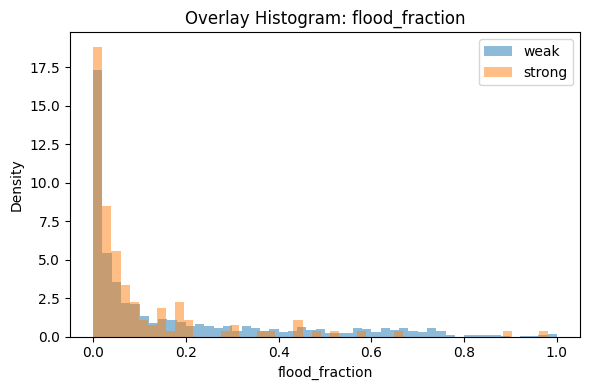

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


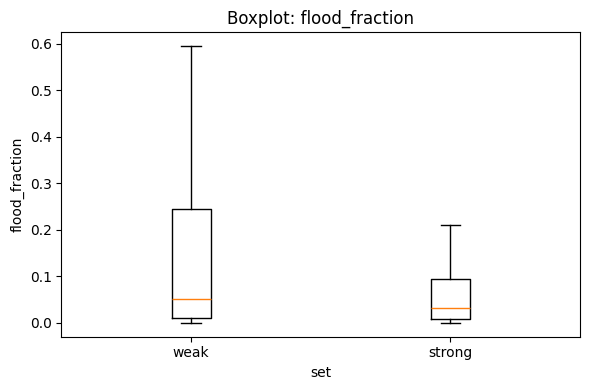

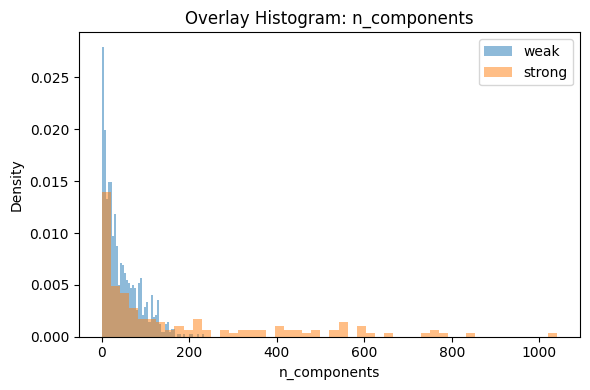

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


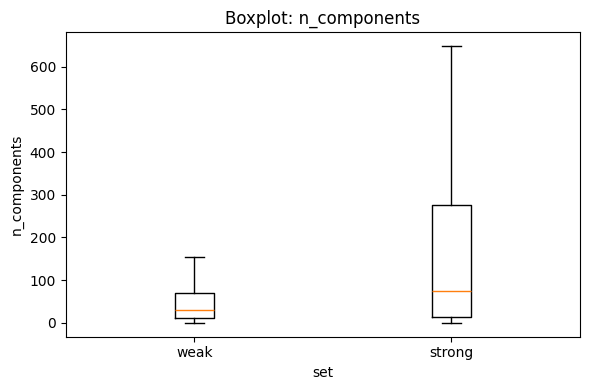

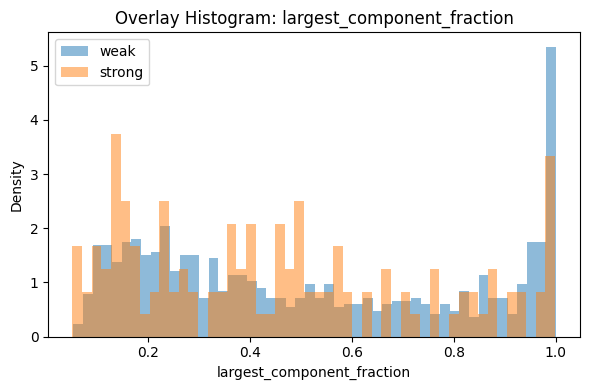

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


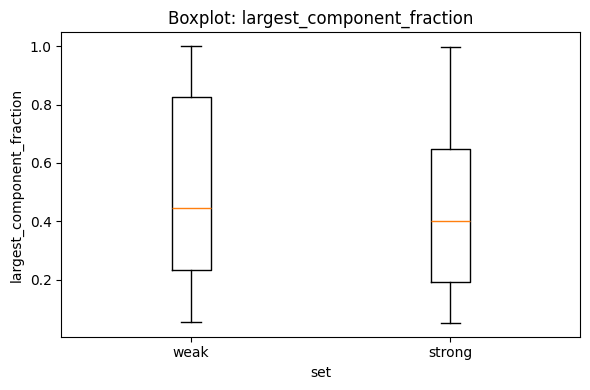

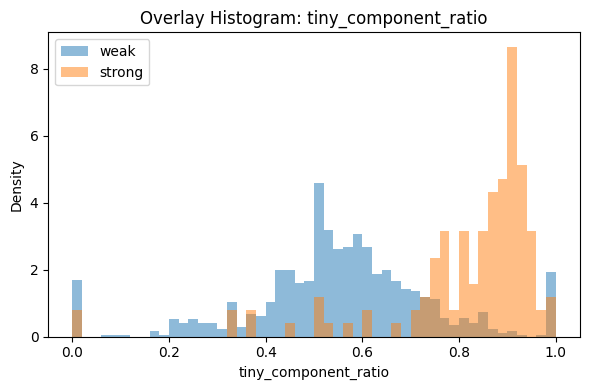

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


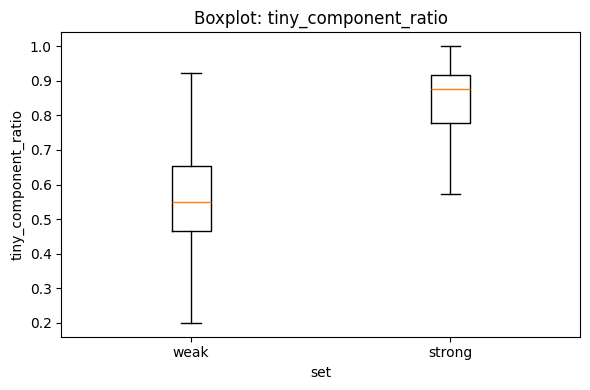

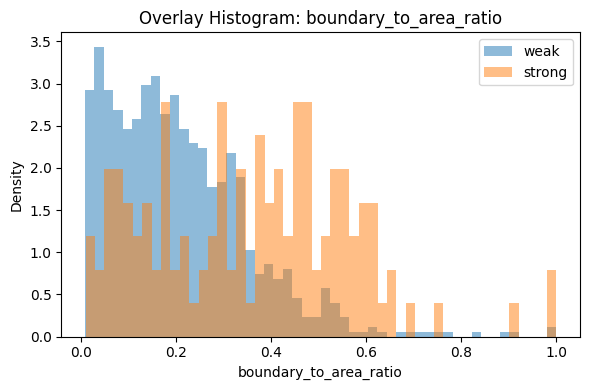

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


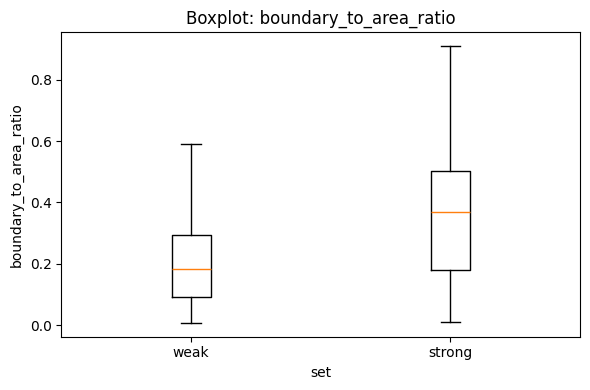

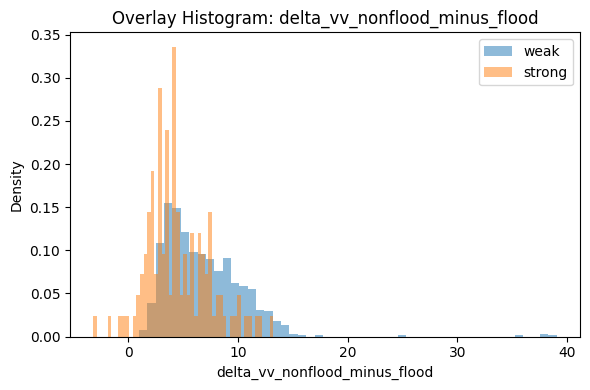

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


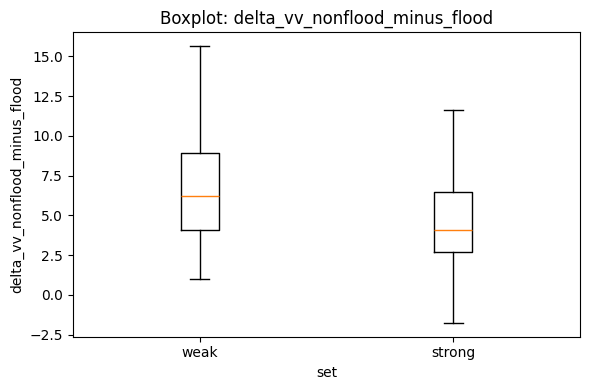

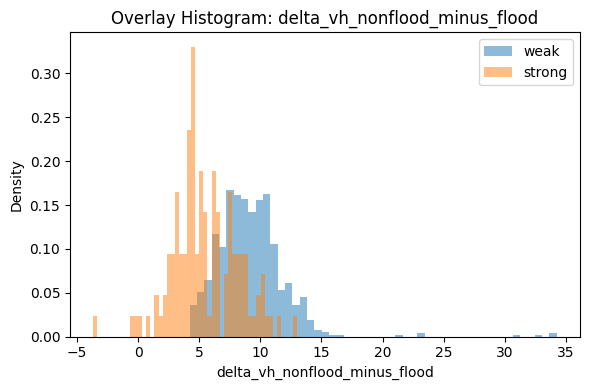

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


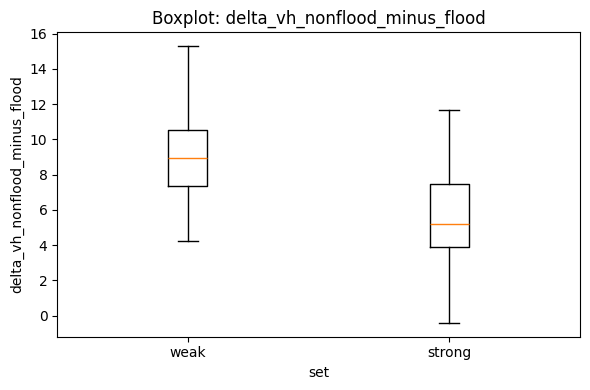

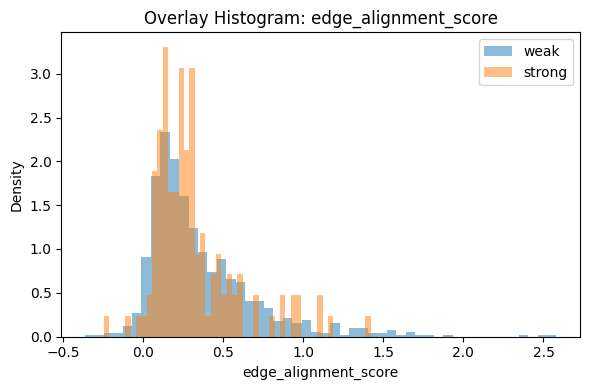

C:\Users\bumba\AppData\Local\Temp\ipykernel_11744\1125632694.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


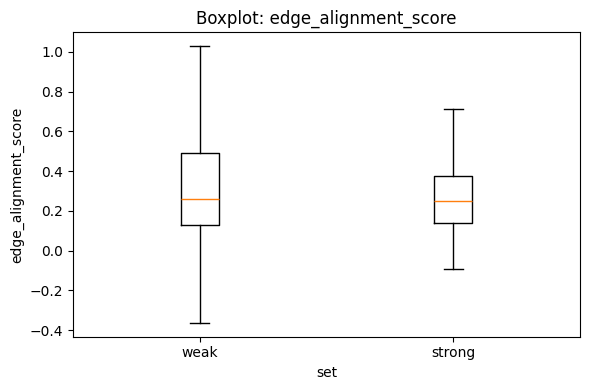

In [10]:
# ---- Distribution Comparison (No Overlap) ----
numeric_metrics = [c for c in METRIC_COLUMNS if c != "tile_id"]

def _summary_stats(vals):
    v = finite_vals(vals)
    if v.size == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "p10": np.nan,
            "p25": np.nan,
            "p75": np.nan,
            "p90": np.nan
        }
    return {
        "count": int(v.size),
        "mean": float(v.mean()),
        "median": float(np.median(v)),
        "std": float(v.std(ddof=1)) if v.size > 1 else np.nan,
        "p10": float(np.percentile(v, 10)),
        "p25": float(np.percentile(v, 25)),
        "p75": float(np.percentile(v, 75)),
        "p90": float(np.percentile(v, 90))
    }

summary_rows = []
for set_name, df in [("weak", weak_metrics_df), ("strong", strong_metrics_df)]:
    for metric in numeric_metrics:
        stats = _summary_stats(df[metric] if metric in df.columns else [])
        stats["set"] = set_name
        stats["metric"] = metric
        summary_rows.append(stats)

summary_df = pd.DataFrame(summary_rows, columns=[
    "set", "metric", "count", "mean", "median", "std", "p10", "p25", "p75", "p90"
])
summary_df.to_csv(out_path / "weak_vs_strong_summary.csv", index=False)

compare_metrics = [
    "flood_fraction",
    "n_components",
    "largest_component_fraction",
    "tiny_component_ratio",
    "boundary_to_area_ratio",
    "delta_vv_nonflood_minus_flood",
    "delta_vh_nonflood_minus_flood",
    "edge_alignment_score"
]

def _smd_mean_diff(a, b):
    a = finite_vals(a)
    b = finite_vals(b)
    if a.size < 2 or b.size < 2:
        return np.nan
    var_a = a.var(ddof=1)
    var_b = b.var(ddof=1)
    pooled = ((a.size - 1) * var_a + (b.size - 1) * var_b) / max(a.size + b.size - 2, 1)
    if pooled <= 0 or not np.isfinite(pooled):
        return np.nan
    return float((a.mean() - b.mean()) / np.sqrt(pooled))

def _shared_hist(a, b, bins=50):
    a = finite_vals(a)
    b = finite_vals(b)
    if a.size == 0 or b.size == 0:
        return None, None, None
    vmin = float(min(a.min(), b.min()))
    vmax = float(max(a.max(), b.max()))
    if vmin == vmax:
        vmin -= 0.5
        vmax += 0.5
    counts_a, edges = np.histogram(a, bins=bins, range=(vmin, vmax))
    counts_b, _ = np.histogram(b, bins=edges)
    return counts_a, counts_b, edges

def _js_divergence(p, q):
    m = 0.5 * (p + q)
    def _kl(a, b):
        mask = a > 0
        return float(np.sum(a[mask] * np.log(a[mask] / b[mask])))
    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)

dist_rows = []
for metric in compare_metrics:
    w = weak_metrics_df[metric] if metric in weak_metrics_df.columns else []
    s = strong_metrics_df[metric] if metric in strong_metrics_df.columns else []
    w_vals = finite_vals(w)
    s_vals = finite_vals(s)
    weak_n = int(w_vals.size)
    strong_n = int(s_vals.size)

    smd = _smd_mean_diff(w_vals, s_vals)

    counts_w, counts_s, edges = _shared_hist(w_vals, s_vals, bins=50)
    if counts_w is None:
        js = np.nan
        w1 = np.nan
        overlap = np.nan
    else:
        total_w = counts_w.sum()
        total_s = counts_s.sum()
        if total_w == 0 or total_s == 0:
            js = np.nan
            w1 = np.nan
            overlap = np.nan
        else:
            p = counts_w / total_w
            q = counts_s / total_s
            js = _js_divergence(p, q)
            cdf_p = np.cumsum(p)
            cdf_q = np.cumsum(q)
            bin_widths = np.diff(edges)
            w1 = float(np.sum(np.abs(cdf_p - cdf_q) * bin_widths))
            overlap = float(np.sum(np.minimum(p, q)))

    dist_rows.append({
        "metric": metric,
        "smd_mean_diff": smd,
        "js_divergence": js,
        "wasserstein1": w1,
        "hist_overlap": overlap,
        "weak_n": weak_n,
        "strong_n": strong_n
    })

dist_df = pd.DataFrame(dist_rows).sort_values("metric").reset_index(drop=True)
dist_df.to_csv(out_path / "weak_vs_strong_distribution_distances.csv", index=False)

for metric in compare_metrics:
    w_vals = finite_vals(weak_metrics_df[metric]) if metric in weak_metrics_df.columns else np.array([])
    s_vals = finite_vals(strong_metrics_df[metric]) if metric in strong_metrics_df.columns else np.array([])
    if w_vals.size == 0 and s_vals.size == 0:
        print(f"No data to plot for {metric}.")
        continue

    plt.figure(figsize=(6, 4))
    if w_vals.size > 0:
        plt.hist(w_vals, bins=50, density=True, alpha=0.5, label="weak")
    if s_vals.size > 0:
        plt.hist(s_vals, bins=50, density=True, alpha=0.5, label="strong")
    plt.title(f"Overlay Histogram: {metric}")
    plt.xlabel(metric)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path / f"overlay_hist_{metric}.png", dpi=150)
    plt.show()

    data = []
    labels = []
    if w_vals.size > 0:
        data.append(w_vals)
        labels.append("weak")
    if s_vals.size > 0:
        data.append(s_vals)
        labels.append("strong")
    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(f"Boxplot: {metric}")
    plt.xlabel("set")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.savefig(out_path / f"box_{metric}.png", dpi=150)
    plt.show()


## Viability Scorecard (No Overlap)

**Purpose:** Convert distribution distances into a simple pass/fail scorecard for weak-label viability.
**Inputs/outputs:** Inputs are `dist_df` and heuristic thresholds; output is `viability_scorecard_no_overlap.csv`.
**Why it matters:** In a zero-overlap setting, distributional similarity is the only quantitative evidence for weak-label usability.

**Heuristic thresholds (adjustable):**
- `min_hist_overlap`: minimum histogram overlap for acceptable similarity
- `max_js_divergence`: maximum Jensen-Shannon divergence allowed
- `max_abs_smd`: maximum absolute standardized mean difference


In [11]:
# ---- Viability Scorecard (No Overlap) ----
min_hist_overlap = 0.65
max_js_divergence = 0.15
max_abs_smd = 0.50

score_rows = []
for row in dist_df.itertuples(index=False):
    if not (np.isfinite(row.hist_overlap) and np.isfinite(row.js_divergence) and np.isfinite(row.smd_mean_diff)):
        passed = False
    else:
        passed = (row.hist_overlap >= min_hist_overlap) and (row.js_divergence <= max_js_divergence) and (abs(row.smd_mean_diff) <= max_abs_smd)
    score_rows.append({
        "metric": row.metric,
        "pass": bool(passed),
        "hist_overlap": row.hist_overlap,
        "js_divergence": row.js_divergence,
        "smd_mean_diff": row.smd_mean_diff
    })

scorecard_df = pd.DataFrame(score_rows)
scorecard_df.to_csv(out_path / "viability_scorecard_no_overlap.csv", index=False)

pass_rate = float(scorecard_df["pass"].mean()) if len(scorecard_df) > 0 else np.nan
print("Viability pass rate:", pass_rate)
scorecard_df


Viability pass rate: 0.375


,metric,pass,hist_overlap,js_divergence,smd_mean_diff
0,boundary_to_area_ratio,False,0.561149,0.144955,-0.980194
1,delta_vh_nonflood_minus_flood,False,0.466992,0.235169,1.283933
2,delta_vv_nonflood_minus_flood,False,0.698166,0.094378,0.637867
3,edge_alignment_score,True,0.757498,0.055459,0.125245
4,flood_fraction,True,0.775074,0.081214,0.330482
5,largest_component_fraction,True,0.691992,0.090282,0.210498
6,n_components,False,0.661004,0.130646,-1.488911
7,tiny_component_ratio,False,0.266491,0.393525,-1.389398


## End-of-Notebook Sanity Prints

**Purpose:** Provide quick, human-readable checks that the pipeline ran and produced the expected artifacts.
**Inputs/outputs:** Inputs are `weak_metrics_df`, `strong_metrics_df`, and `dist_df`; outputs are printed summaries.
**Why it matters:** Validates that both sets were processed and highlights the most divergent metrics.


In [12]:
# ---- Sanity Prints ----
print("Weak tiles processed:", len(weak_metrics_df))
print("Strong tiles processed:", len(strong_metrics_df))

print("Weak metrics head:")
print(weak_metrics_df.head())
print("Strong metrics head:")
print(strong_metrics_df.head())

if len(dist_df) > 0:
    worst = dist_df.sort_values("hist_overlap", ascending=True).head(8)
    print("Worst 8 metrics by hist_overlap:")
    print(worst[["metric", "hist_overlap", "js_divergence", "smd_mean_diff"]])
else:
    print("No distribution distances to summarize.")


Weak tiles processed: 906
Strong tiles processed: 138
Weak metrics head:
         tile_id  flood_fraction  mask_area_px  n_components  \
0  India_1029501        0.003685           966            11   
1  India_1064251        0.024445          6408            37   
2  India_1068450        0.559757        146737             4   
3  India_1080875        0.876556        229784             3   
4  India_1098917        0.009842          2580            37   

   largest_component_fraction  tiny_component_ratio  boundary_length_px  \
0                    0.478261              0.636364                 300   
1                    0.435861              0.540541                1334   
2                    0.929895              0.000000                3212   
3                    0.999412              0.333333                3940   
4                    0.208140              0.648649                 901   

   boundary_to_area_ratio  vv_flood_mean  vv_nonflood_mean  \
0                0.310559    